# SE-ResNeXt-50 Natural-Orientation Native-CAM Training for KL Grading

This fixed training notebook preserves the natural orientation of every knee so the
checkpoint can accept bilateral or single-knee radiographs without laterality metadata.
Training uses horizontal flipping, mild rotation, mild brightness/contrast variation,
and low-probability mild gamma correction. Gaussian noise and affine shear/translation
are excluded because the knee-specific evidence and completed DenseNet ablation showed
damage to subtle early-grade features or CAM localization.

The architecture retains the final spatial tensor, applies a 1x1 five-class convolution,
and globally averages those maps to produce CE logits. Every run creates a unique
UTC-timestamped directory containing checkpoints, metrics, predictions, CAM audit,
manifest, figures, and Markdown report.

Evidence: Prezja et al., *Exploring the Efficacy of Base Data Augmentation Methods
in Deep Learning-Based Radiograph Classification of Knee Joint Osteoarthritis*,
Algorithms 2024, DOI: https://doi.org/10.3390/a17010008. Rotation was the strongest
supportive augmentation in that study, whereas even 5% Gaussian noise damaged subtle
KL0-1 evidence. Mild gamma is retained here as a controlled exposure-robustness
hypothesis and must earn promotion through validation metrics and the CAM audit.


## Execution

Run every cell from top to bottom in a fresh Colab GPU runtime. The dataset is
extracted from Drive when the archive exists. The notebook trains on `train`,
selects checkpoints only on `val`, and evaluates `test` once after selection.


In [ ]:
import csv
import hashlib
import json
import os
import random
import subprocess
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("Not running in Colab; Drive mount skipped.")

try:
    import timm
except ImportError:
    subprocess.run(["pip", "install", "-q", "timm"], check=True)
    import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

dataset_zip = Path("/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip")
if dataset_zip.exists():
    subprocess.run(
        ["unzip", "-q", "-o", str(dataset_zip), "-d", "/content/Datasets"],
        check=True,
    )

DATASET_ROOT = Path("/content/Datasets/kaggle_knee_osteoarthritis")
RUN_TIMESTAMP = datetime.now(timezone.utc).strftime(
    "%Y-%m-%d_%H-%M-%S_%f_UTC"
)
RUN_DIR = Path("/content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints") / f"{RUN_TIMESTAMP}_natural_orientation_flip_gamma_native_cam_ce"
RUN_DIR.mkdir(parents=True, exist_ok=False)
print(f"Run directory: {RUN_DIR}")


Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Run directory: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-07-25_01-50-53_962450_UTC_natural_orientation_flip_gamma_native_cam_ce


## Data Preparation

Images are deduplicated across splits. Right knees are mirrored so every image
follows the same medial/lateral convention. Training uses mild rotation,
brightness/contrast jitter, one small random erase, and full inverse-frequency
sampling. Validation and test preprocessing are deterministic.


In [ ]:
class SquarePad:
    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            cv2.BORDER_CONSTANT,
            value=[0, 0, 0],
        )


class CLAHE:
    def __call__(self, image):
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(lab)
        lightness = cv2.createCLAHE(
            clipLimit=2.0, tileGridSize=(8, 8)
        ).apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)),
            cv2.COLOR_LAB2RGB,
        )


class RandomGammaCorrection:
    """Apply mild gamma correction with a reproducible training-only probability."""

    def __init__(self, gamma_range=(0.90, 1.10), probability=0.20):
        low, high = gamma_range
        if low <= 0 or high < low:
            raise ValueError("gamma_range must contain positive ordered values")
        if not 0.0 <= probability <= 1.0:
            raise ValueError("probability must be between 0 and 1")
        self.gamma_range = (float(low), float(high))
        self.probability = float(probability)

    def __call__(self, image):
        if torch.rand(1).item() >= self.probability:
            return image
        gamma = torch.empty(1).uniform_(*self.gamma_range).item()
        return transforms.functional.adjust_gamma(image, gamma=gamma, gain=1.0)


train_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.50),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    RandomGammaCorrection(gamma_range=(0.90, 1.10), probability=0.20),
    transforms.Resize((400, 400)),
    transforms.RandomCrop(384),
    transforms.ToTensor(),
    transforms.RandomErasing(
        p=0.10, scale=(0.02, 0.05), ratio=(0.5, 2.0), value=0
    ),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

evaluation_transform = transforms.Compose([
    SquarePad(),
    CLAHE(),
    transforms.ToPILImage(),
    transforms.Resize((400, 400)),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def file_digest(path):
    digest = hashlib.sha256()
    with open(path, "rb") as image_file:
        for chunk in iter(lambda: image_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


class KneeDataset(Dataset):
    def __init__(self, split, transform, excluded_hashes=None):
        self.transform = transform
        split_dir = DATASET_ROOT / split
        if not split_dir.is_dir():
            raise FileNotFoundError(f"Dataset split is missing: {split_dir}")

        excluded_hashes = excluded_hashes or set()
        retained_hashes = set()
        self.paths = []
        self.labels = []
        for grade in range(5):
            grade_dir = split_dir / str(grade)
            for path in sorted(grade_dir.iterdir()):
                if path.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
                    continue
                digest = file_digest(path)
                if digest in excluded_hashes or digest in retained_hashes:
                    continue
                retained_hashes.add(digest)
                self.paths.append(str(path))
                self.labels.append(grade)
        self.image_hashes = retained_hashes
        print(f"{split}: {len(self.paths)} unique images")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        path = self.paths[index]
        image = cv2.imread(path)
        if image is None:
            raise IOError(f"Could not read image: {path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return self.transform(image), self.labels[index], path


In [ ]:
train_dataset = KneeDataset("train", train_transform)
validation_dataset = KneeDataset(
    "val", evaluation_transform, train_dataset.image_hashes
)

class_counts = Counter(train_dataset.labels)
sample_weights = [
    1.0 / class_counts[label] for label in train_dataset.labels
]
sampler_generator = torch.Generator().manual_seed(42)
balanced_sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=sampler_generator,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=48,
    sampler=balanced_sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    generator=sampler_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=48,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)
print("Class counts:", dict(sorted(class_counts.items())))
print(
    f"Batches: train={{len(train_loader)}}, "
    f"validation={{len(validation_loader)}}"
)


train: 5778 unique images
val: 826 unique images
Class counts: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Batches: train={len(train_loader)}, validation={len(validation_loader)}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Model: `natural_final_native_cam_ce`

SE-ResNeXt-50 exposes its final semantic feature tensor. A 1x1 convolution produces
five grade maps, and global average pooling produces the logits. Orientation policy is
recorded separately from the unchanged spatially linear native-CAM head.


In [ ]:
class SEResNeXt50NativeCAM(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            "seresnext50_32x4d",
            pretrained=pretrained,
            features_only=True,
            out_indices=(4,),
        )
        channels = self.backbone.feature_info.channels()[0]
        self.class_conv = nn.Conv2d(channels, 5, kernel_size=1)

    def class_maps(self, images):
        return self.class_conv(self.backbone(images)[0])

    def forward(self, images):
        return self.class_maps(images).mean(dim=(2, 3))

    def native_cam(self, images, class_indices=None):
        with torch.no_grad():
            maps = self.class_maps(images)
            logits = maps.mean(dim=(2, 3))
            if class_indices is None:
                class_indices = logits.argmax(dim=1)
            class_indices = torch.as_tensor(
                class_indices, device=images.device, dtype=torch.long
            ).reshape(-1)
            selected = maps[
                torch.arange(images.size(0), device=images.device),
                class_indices,
            ]
            selected = F.relu(selected).unsqueeze(1)
            selected = F.interpolate(
                selected,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False,
            ).squeeze(1)
            maxima = selected.flatten(1).amax(1).clamp_min(1e-8)
            selected = selected / maxima[:, None, None]
        return selected, logits

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_final_stages(self):
        for parameter in self.parameters():
            parameter.requires_grad = False
        matched = 0
        for name, parameter in self.backbone.named_parameters():
            if any(token in name for token in ("layer3", "layer4", "stages.2", "stages.3")):
                parameter.requires_grad = True
                matched += parameter.numel()
        if matched == 0:
            raise RuntimeError("Could not resolve the final backbone stages.")
        for parameter in self.class_conv.parameters():
            parameter.requires_grad = True

    def unfreeze_all(self):
        for parameter in self.parameters():
            parameter.requires_grad = True


## Training and Validation

Training is fixed to three stages: five head-only epochs, fifteen final-stage
epochs, and ten full fine-tuning epochs. Checkpoint selection uses validation QWK,
macro F1/recall, Grade 1 recall, average precision, and AUC. No test result is used
during optimization or checkpoint selection.


In [ ]:
def calculate_metrics(labels, predictions, probabilities):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, labels=[0, 1, 2, 3, 4],
        average="macro", zero_division=0
    )
    one_hot = np.eye(5)[labels]
    metrics = {
        "accuracy": float(accuracy_score(labels, predictions)),
        "qwk": float(cohen_kappa_score(labels, predictions, weights="quadratic")),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "grade1_recall": float(
            recall_score(labels == 1, predictions == 1, zero_division=0)
        ),
        "macro_ap": float(
            average_precision_score(one_hot, probabilities, average="macro")
        ),
        "macro_auc": float(
            roc_auc_score(one_hot, probabilities, average="macro")
        ),
    }
    metrics["selection_score"] = float(
        0.40 * metrics["qwk"]
        + 0.20 * metrics["macro_f1"]
        + 0.10 * metrics["macro_recall"]
        + 0.10 * metrics["grade1_recall"]
        + 0.15 * metrics["macro_ap"]
        + 0.05 * metrics["macro_auc"]
    )
    return metrics


def train_one_epoch(model, loader, optimizer, scaler, description):
    model.train()
    running_loss = 0.0
    for images, labels, _ in tqdm.tqdm(loader, desc=description, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda",
        ):
            loss = F.cross_entropy(model(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, description):
    model.eval()
    labels_all, predictions_all, probabilities_all, paths_all = [], [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for images, labels, paths in tqdm.tqdm(loader, desc=description, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probabilities = F.softmax(logits.float(), dim=1)
            total_loss += F.cross_entropy(logits, labels).item() * labels.size(0)
            labels_all.extend(labels.cpu().numpy())
            predictions_all.extend(probabilities.argmax(1).cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())
            paths_all.extend(paths)
    metrics = calculate_metrics(
        labels_all, predictions_all, probabilities_all
    )
    metrics["loss"] = total_loss / len(loader.dataset)
    return (
        metrics,
        np.asarray(labels_all),
        np.asarray(predictions_all),
        np.asarray(probabilities_all),
        paths_all,
    )


def load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


In [ ]:
model = SEResNeXt50NativeCAM(pretrained=True).to(device)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
stage2_path = RUN_DIR / "stage2_best_model.pth"
best_path = RUN_DIR / "best_model.pth"
last_path = RUN_DIR / "last_model.pth"
history = []
best_stage2_score = -float("inf")
best_selection_score = -float("inf")
global_epoch = 0

for stage_name, stage_epochs in (("warmup", 5), ("coarse", 15), ("finetune", 10)):
    if stage_name == "warmup":
        model.freeze_backbone()
        optimizer = optim.AdamW(
            model.class_conv.parameters(), lr=3e-4, weight_decay=1e-4
        )
        scheduler = None
    elif stage_name == "coarse":
        model.unfreeze_final_stages()
        optimizer = optim.AdamW(
            [
                {
                    "params": [
                        parameter for parameter in model.backbone.parameters()
                        if parameter.requires_grad
                    ],
                    "lr": 3e-5,
                },
                {"params": model.class_conv.parameters(), "lr": 3e-4},
            ],
            weight_decay=1e-4,
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=15, eta_min=1e-7
        )
    else:
        if not stage2_path.exists():
            raise FileNotFoundError("Stage 2 did not produce a checkpoint.")
        model.load_state_dict(load_checkpoint(stage2_path)["model_state_dict"])
        model.unfreeze_all()
        optimizer = optim.AdamW(
            model.parameters(), lr=1e-5, weight_decay=1e-3
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=10, eta_min=1e-7
        )

    for stage_epoch in range(stage_epochs):
        global_epoch += 1
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            f"{stage_name} {stage_epoch + 1}/{stage_epochs}",
        )
        validation_metrics, _, _, _, _ = evaluate(
            model, validation_loader, "VALIDATE"
        )
        history.append({
            "epoch": global_epoch,
            "stage": stage_name,
            "train_loss": train_loss,
            **validation_metrics,
        })
        print(
            f"Epoch {global_epoch:02d} | {stage_name} | "
            f"QWK={validation_metrics['qwk']:.4f} | "
            f"F1={validation_metrics['macro_f1']:.4f} | "
            f"G1R={validation_metrics['grade1_recall']:.4f} | "
            f"AP={validation_metrics['macro_ap']:.4f} | "
            f"selection={validation_metrics['selection_score']:.4f}"
        )
        if scheduler is not None:
            scheduler.step()

        payload = {
            "model_state_dict": model.state_dict(),
            "epoch": global_epoch,
            "stage": stage_name,
            "architecture": "natural_final_native_cam_ce",
            "model_name": "seresnext50_32x4d",
            "loss_type": "ce",
            "validation_metrics": validation_metrics,
            "history": history,
            "run_timestamp": RUN_TIMESTAMP,
            "fixed_production_config": {
                "input_resize": 400,
                "input_crop": 384,
                "batch_size": 48,
                "sampler": "full_inverse_frequency",
                "canonicalize_laterality": False,
                "horizontal_flip_probability": 0.50,
                "gamma_probability": 0.20,
                "gamma_range": [0.90, 1.10],
                "gaussian_noise_probability": 0.0,
                "stage_epochs": [5, 15, 10],
                "learning_rates": [3e-4, 3e-5, 1e-5],
                "native_cam": True,
            },
        }
        if stage_name == "coarse" and validation_metrics["selection_score"] > best_stage2_score:
            best_stage2_score = validation_metrics["selection_score"]
            torch.save(payload, stage2_path)
        if (
            stage_name in {"coarse", "finetune"}
            and validation_metrics["selection_score"] > best_selection_score
        ):
            best_selection_score = validation_metrics["selection_score"]
            torch.save(payload, best_path)
        torch.save(payload, last_path)

if not best_path.exists():
    raise RuntimeError("Training finished without a final checkpoint.")
with open(RUN_DIR / "epoch_metrics.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=history[0].keys())
    writer.writeheader()
    writer.writerows(history)
print(f"Selected checkpoint: {best_path}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B /  111MB            

model.safetensors: downloading bytes:           |  0.00B            

warmup 1/5:   0%|          | 0/121 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 01 | warmup | QWK=0.2754 | F1=0.2679 | G1R=0.1373 | AP=0.3248 | selection=0.2925


...

Epoch 26 | finetune | QWK=0.7910 | F1=0.6602 | G1R=0.3660 | AP=0.7099 | selection=0.7035


Epoch 27 | finetune | QWK=0.7903 | F1=0.6599 | G1R=0.3660 | AP=0.7123 | selection=0.7031


Epoch 28 | finetune | QWK=0.7899 | F1=0.6617 | G1R=0.3856 | AP=0.7139 | selection=0.7061


Epoch 29 | finetune | QWK=0.7885 | F1=0.6674 | G1R=0.3725 | AP=0.7139 | selection=0.7056


Epoch 30 | finetune | QWK=0.7909 | F1=0.6658 | G1R=0.3660 | AP=0.7117 | selection=0.7050
Selected checkpoint: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-07-25_01-50-53_962450_UTC_natural_orientation_flip_gamma_native_cam_ce/best_model.pth


## Locked Test Evaluation

The test split is loaded only after the validation-selected checkpoint exists.
Predictions and probabilities are saved so the report can be reproduced without
rerunning inference.


test: 1656 unique images


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
TEST:   0%|          | 0/35 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality(

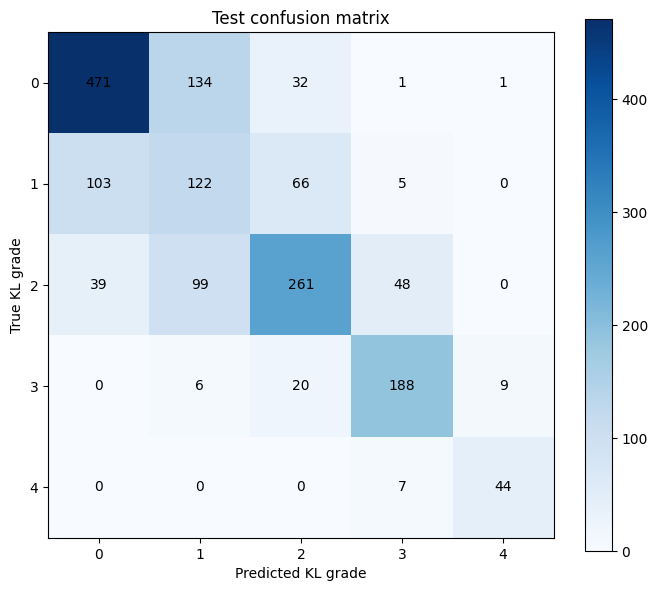

{
  "accuracy": 0.6557971014492754,
  "qwk": 0.8215501656080799,
  "macro_precision": 0.6729583505236494,
  "macro_recall": 0.6877876813766473,
  "macro_f1": 0.6780895833029407,
  "grade1_recall": 0.41216216216216217,
  "macro_ap": 0.7298951747361356,
  "macro_auc": 0.8980188302621649,
  "selection_score": 0.7286181849812297,
  "loss": 0.7675830566364786
}
              precision    recall  f1-score   support

     Grade 0       0.77      0.74      0.75       639
     Grade 1       0.34      0.41      0.37       296
     Grade 2       0.69      0.58      0.63       447
     Grade 3       0.76      0.84      0.80       223
     Grade 4       0.81      0.86      0.84        51

    accuracy                           0.66      1656
   macro avg       0.67      0.69      0.68      1656
weighted avg       0.67      0.66      0.66      1656



In [ ]:
test_dataset = KneeDataset(
    "test",
    evaluation_transform,
    train_dataset.image_hashes | validation_dataset.image_hashes,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=48,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

best_checkpoint = load_checkpoint(best_path)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()
test_metrics, test_true, test_predicted, test_probabilities, test_paths = evaluate(
    model, test_loader, "TEST"
)

prediction_rows = []
for path, true_grade, predicted_grade, probabilities in zip(
    test_paths, test_true, test_predicted, test_probabilities
):
    prediction_rows.append({
        "path": path,
        "true_grade": int(true_grade),
        "predicted_grade": int(predicted_grade),
        **{
            f"grade_{grade}_probability": float(probabilities[grade])
            for grade in range(5)
        },
    })
with open(RUN_DIR / "test_predictions.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=prediction_rows[0].keys())
    writer.writeheader()
    writer.writerows(prediction_rows)
with open(RUN_DIR / "test_metrics.json", "w") as handle:
    json.dump(test_metrics, handle, indent=2)

matrix = confusion_matrix(test_true, test_predicted, labels=[0, 1, 2, 3, 4])
figure, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(matrix, cmap="Blues")
for row in range(5):
    for column in range(5):
        axis.text(column, row, matrix[row, column], ha="center", va="center")
axis.set(
    title="Test confusion matrix",
    xlabel="Predicted KL grade",
    ylabel="True KL grade",
    xticks=range(5),
    yticks=range(5),
)
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(RUN_DIR / "test_confusion_matrix.png", dpi=180)
plt.show()

print(json.dumps(test_metrics, indent=2))
print(classification_report(
    test_true,
    test_predicted,
    labels=[0, 1, 2, 3, 4],
    target_names=[f"Grade {grade}" for grade in range(5)],
    zero_division=0,
))


## Native-CAM Audit

Up to 50 validation knees per grade are audited. Predicted- and true-class maps
are saved for the worst cases. The central joint mask is only an anatomical proxy,
not an expert joint-space segmentation; the report must not describe these maps as
lesion masks.


NATIVE CAM AUDIT: 100%|██████████| 227/227 [00:13<00:00, 16.80it/s]


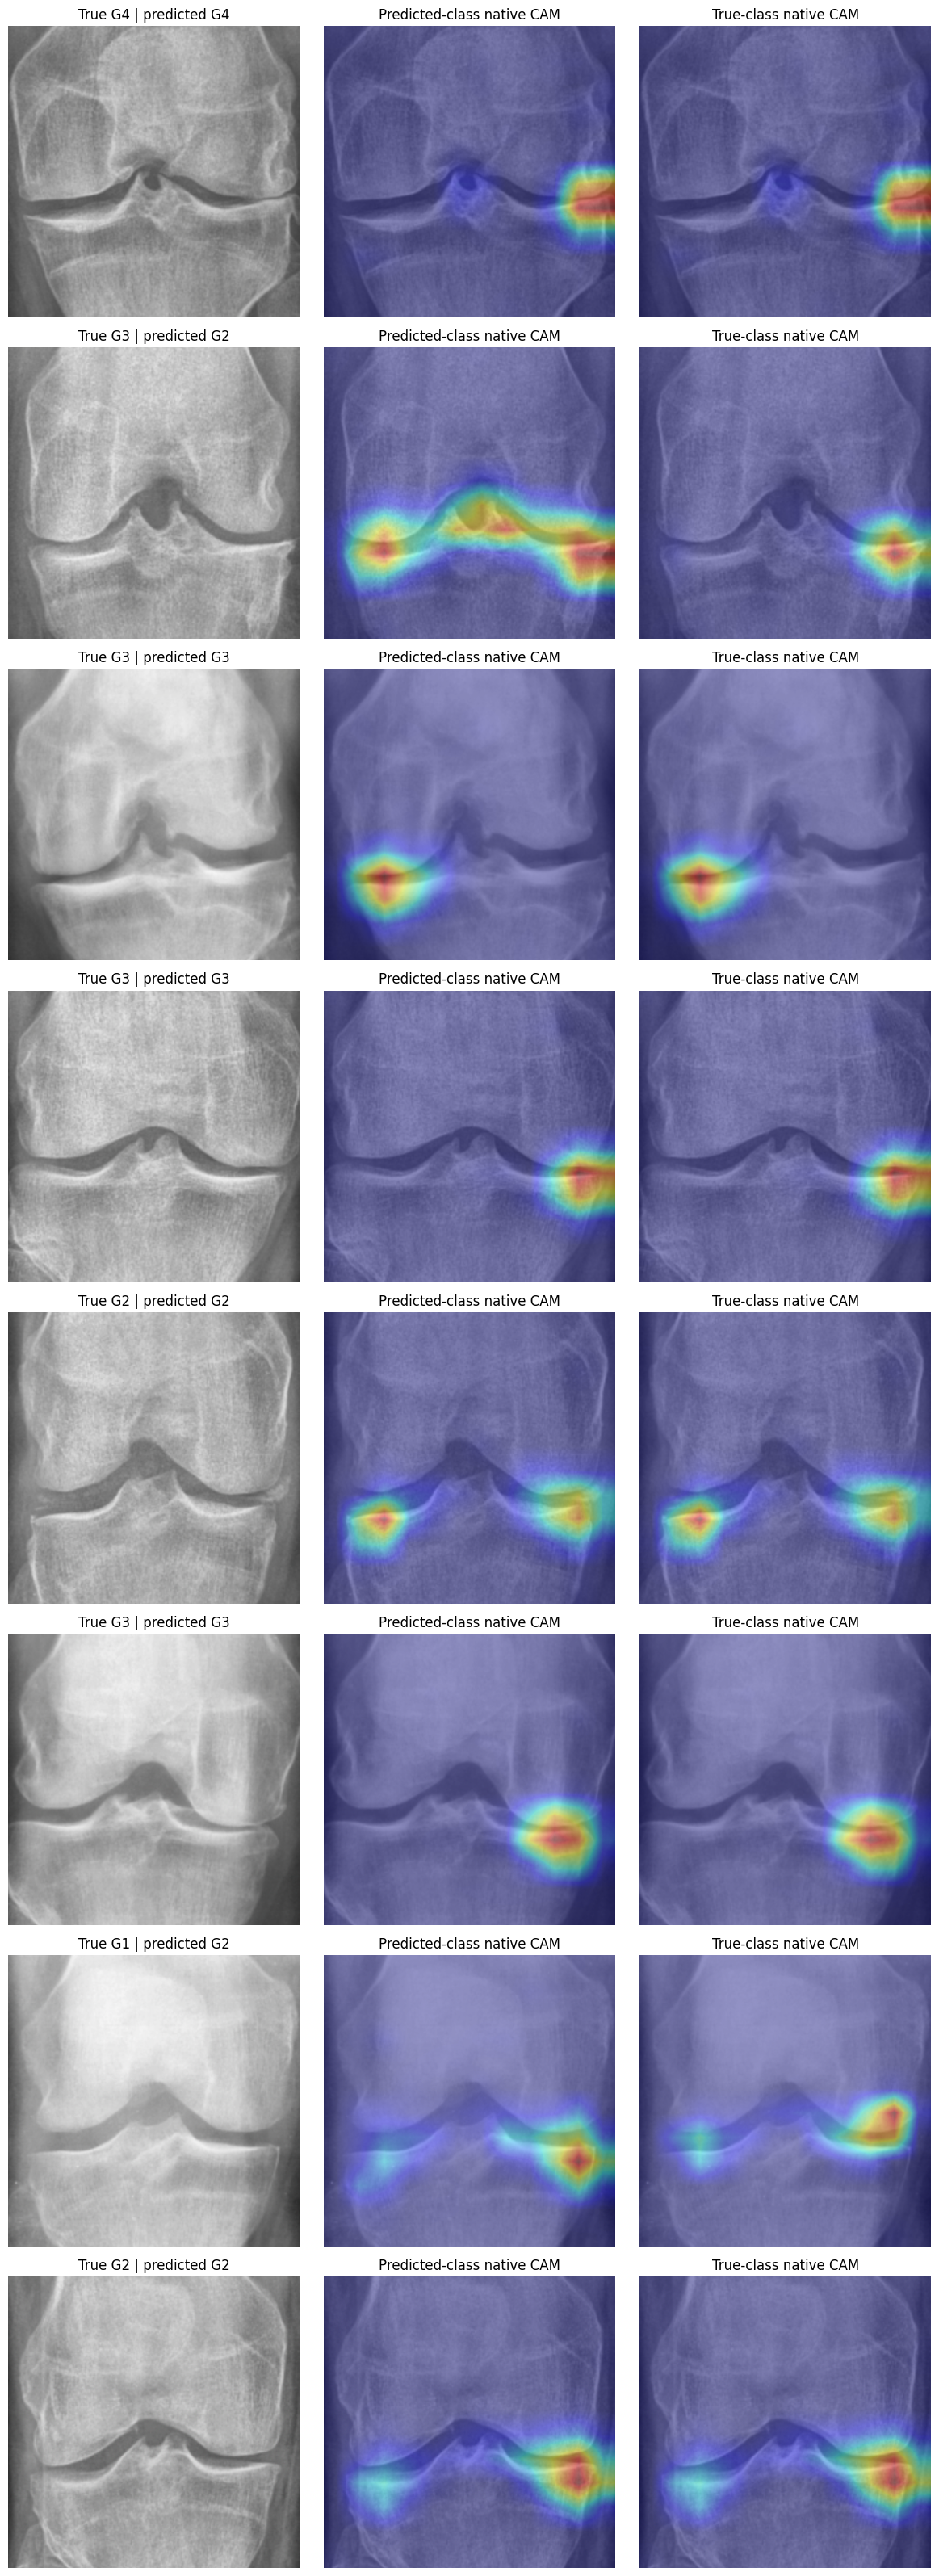

{
  "audited_cases": 227,
  "joint_energy": 0.8516493903632197,
  "border_energy": 0.09901902724574312,
  "lower_tibia_energy": 0.08782337682669471,
  "peak_inside_joint_rate": 0.9911894273127754
}


In [ ]:
def cam_geometry(cam):
    height, width = cam.shape
    joint = np.zeros((height, width), dtype=bool)
    joint[
        int(0.28 * height):int(0.72 * height),
        int(0.06 * width):int(0.94 * width),
    ] = True
    border = np.ones((height, width), dtype=bool)
    border[
        int(0.08 * height):int(0.92 * height),
        int(0.08 * width):int(0.92 * width),
    ] = False
    lower_tibia = np.zeros((height, width), dtype=bool)
    lower_tibia[int(0.72 * height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak = np.unravel_index(np.argmax(cam), cam.shape)
    return {
        "joint_energy": float(cam[joint].sum()) / total,
        "border_energy": float(cam[border].sum()) / total,
        "lower_tibia_energy": float(cam[lower_tibia].sum()) / total,
        "peak_inside_joint": int(joint[peak]),
    }


rng = np.random.default_rng(42)
audit_indices = []
labels_array = np.asarray(validation_dataset.labels)
for grade in range(5):
    grade_indices = np.flatnonzero(labels_array == grade)
    rng.shuffle(grade_indices)
    audit_indices.extend(grade_indices[:min(50, len(grade_indices))].tolist())

cam_rows = []
cached_maps = {}
for index in tqdm.tqdm(audit_indices, desc="NATIVE CAM AUDIT"):
    tensor, true_grade, path = validation_dataset[index]
    batch = tensor[None].to(device)
    with torch.no_grad():
        logits = model(batch)
        predicted_grade = int(logits.argmax(1).item())
    predicted_cam, _ = model.native_cam(batch, [predicted_grade])
    true_cam, _ = model.native_cam(batch, [int(true_grade)])
    predicted_cam = predicted_cam[0].cpu().numpy()
    true_cam = true_cam[0].cpu().numpy()
    row = {
        "dataset_index": index,
        "path": path,
        "true_grade": int(true_grade),
        "predicted_grade": predicted_grade,
        **{f"predicted_{key}": value for key, value in cam_geometry(predicted_cam).items()},
        **{f"true_{key}": value for key, value in cam_geometry(true_cam).items()},
    }
    cam_rows.append(row)
    cached_maps[index] = (tensor, predicted_cam, true_cam)

with open(RUN_DIR / "native_cam_audit.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=cam_rows[0].keys())
    writer.writeheader()
    writer.writerows(cam_rows)

cam_summary = {
    "audited_cases": len(cam_rows),
    "joint_energy": float(np.mean([row["predicted_joint_energy"] for row in cam_rows])),
    "border_energy": float(np.mean([row["predicted_border_energy"] for row in cam_rows])),
    "lower_tibia_energy": float(np.mean([row["predicted_lower_tibia_energy"] for row in cam_rows])),
    "peak_inside_joint_rate": float(np.mean([row["predicted_peak_inside_joint"] for row in cam_rows])),
}
with open(RUN_DIR / "native_cam_summary.json", "w") as handle:
    json.dump(cam_summary, handle, indent=2)

worst_cases = sorted(
    cam_rows,
    key=lambda row: (
        1 - row["predicted_peak_inside_joint"]
        + row["predicted_border_energy"]
        + row["predicted_lower_tibia_energy"]
    ),
    reverse=True,
)[:8]
mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
figure, axes = plt.subplots(len(worst_cases), 3, figsize=(12, 4 * len(worst_cases)))
for row_index, row in enumerate(worst_cases):
    tensor, predicted_cam, true_cam = cached_maps[row["dataset_index"]]
    display_image = (
        (tensor.cpu() * std + mean)
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )
    axes[row_index, 0].imshow(display_image)
    axes[row_index, 0].set_title(
        f"True G{row['true_grade']} | predicted G{row['predicted_grade']}"
    )
    axes[row_index, 1].imshow(display_image)
    axes[row_index, 1].imshow(predicted_cam, cmap="jet", alpha=0.40)
    axes[row_index, 1].set_title("Predicted-class native CAM")
    axes[row_index, 2].imshow(display_image)
    axes[row_index, 2].imshow(true_cam, cmap="jet", alpha=0.40)
    axes[row_index, 2].set_title("True-class native CAM")
    for axis in axes[row_index]:
        axis.axis("off")
figure.tight_layout()
figure.savefig(RUN_DIR / "native_cam_worst_cases.png", dpi=180)
plt.show()
print(json.dumps(cam_summary, indent=2))


## Reproducible Run Report

The final cell writes the exact run timestamp, fixed configuration, validation
selection metrics, locked-test metrics, CAM audit summary, and artifact paths to
the run directory.


In [ ]:
validation_metrics = best_checkpoint["validation_metrics"]
manifest = {
    "run_timestamp": RUN_TIMESTAMP,
    "run_directory": str(RUN_DIR),
    "model_name": "seresnext50_32x4d",
    "architecture": "natural_final_native_cam_ce",
    "loss": "cross_entropy",
    "input_resize": 400,
    "input_crop": 384,
    "batch_size": 48,
    "sampler": "full_inverse_frequency",
    "canonicalize_laterality": False,
    "orientation_policy": "natural_no_inference_mirroring",
    "augmentation": {
        "horizontal_flip_probability": 0.50,
        "rotation_degrees": 5,
        "brightness": 0.08,
        "contrast": 0.08,
        "gamma_probability": 0.20,
        "gamma_range": [0.90, 1.10],
        "gaussian_noise_probability": 0.0,
    },
    "stages": [
        {"name": "warmup", "epochs": 5, "learning_rate": 3e-4},
        {"name": "coarse", "epochs": 15, "backbone_lr": 3e-5, "head_lr": 3e-4},
        {"name": "finetune", "epochs": 10, "learning_rate": 1e-5},
    ],
    "best_epoch": best_checkpoint["epoch"],
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics,
    "native_cam_summary": cam_summary,
    "selected_checkpoint": str(best_path),
}
with open(RUN_DIR / "run_manifest.json", "w") as handle:
    json.dump(manifest, handle, indent=2)
(RUN_DIR / "SELECTED_CHECKPOINT.txt").write_text(str(best_path) + "\n")

report = f"""# SE-ResNeXt-50 Natural-Orientation Native-CAM Run Report

| Field | Value |
| --- | --- |
| Run timestamp | {RUN_TIMESTAMP} |
| Architecture | `natural_final_native_cam_ce` |
| Loss | Cross-entropy |
| Input | Resize 400, center/random crop 384 |
| Batch size | 48 |
| Sampler | Full inverse-frequency |
| Orientation | Natural; no deterministic inference mirroring |
| Horizontal flip | p=0.50, training only |
| Gamma | 0.90-1.10, p=0.20 |
| Gaussian noise | Disabled |
| Best epoch | {best_checkpoint['epoch']} |
| Selected checkpoint | `{best_path}` |

## Validation Selection Metrics

| QWK | Macro F1 | Macro Recall | Grade 1 Recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: |
| {validation_metrics['qwk']:.4f} | {validation_metrics['macro_f1']:.4f} | {validation_metrics['macro_recall']:.4f} | {validation_metrics['grade1_recall']:.4f} | {validation_metrics['macro_ap']:.4f} | {validation_metrics['macro_auc']:.4f} |

## Locked Test Metrics

| Accuracy | QWK | Macro F1 | Grade 1 Recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: |
| {test_metrics['accuracy']:.4f} | {test_metrics['qwk']:.4f} | {test_metrics['macro_f1']:.4f} | {test_metrics['grade1_recall']:.4f} | {test_metrics['macro_ap']:.4f} | {test_metrics['macro_auc']:.4f} |

## Native-CAM Audit

| Cases | Joint energy | Border energy | Lower-tibia energy | Peak inside joint |
| ---: | ---: | ---: | ---: | ---: |
| {cam_summary['audited_cases']} | {cam_summary['joint_energy']:.4f} | {cam_summary['border_energy']:.4f} | {cam_summary['lower_tibia_energy']:.4f} | {cam_summary['peak_inside_joint_rate']:.4f} |

The native CAM is faithful to the final-linear classifier head, but the joint band
is a coarse anatomical proxy. These heatmaps show model evidence and must not be
presented as expert-validated lesion segmentations.
"""
(RUN_DIR / "report.md").write_text(report, encoding="utf-8")
print(f"Report: {RUN_DIR / 'report.md'}")
print(f"All artifacts: {RUN_DIR}")


Report: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-07-25_01-50-53_962450_UTC_natural_orientation_flip_gamma_native_cam_ce/report.md
All artifacts: /content/drive/MyDrive/Models/seresnext50_32x4d_checkpoints/2026-07-25_01-50-53_962450_UTC_natural_orientation_flip_gamma_native_cam_ce


In [ ]:
try:
    from google.colab import runtime
    print("All artifacts saved. Releasing the Colab runtime.")
    runtime.unassign()
except ImportError:
    print("Not running in Colab; runtime release skipped.")


All artifacts saved. Releasing the Colab runtime.
